# PRODIGY_DS_02

## Task-02: Data Cleaning and Exploratory Data Analysis on Google Play Store Apps Dataset

Objective: Perform data cleaning and exploratory data analysis (EDA) on the Google Play Store Apps dataset to identify trends, relationships, and patterns among various app attributes.

In [5]:
# 1.importing libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme()

import warnings
warnings.filterwarnings("ignore")

In [6]:
# 2.loading the dataset
df = pd.read_csv("googleplaystore.csv")

df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [7]:
# 3.basic info and stats
print("Shape of Dataset:", df.shape)

df.info()

df.describe()

df.describe(include='object')

Shape of Dataset: (10841, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


,App,Category,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,596,1695,1579,10039,10040,8714,842,326,1459,2451


In [8]:
# 4.checking missing values
df.isnull().sum().sort_values(ascending=False)

,0
Rating,1474
Current Ver,8
Android Ver,3
Content Rating,1
Type,1
Size,0
Reviews,0
Category,0
App,0
Price,0


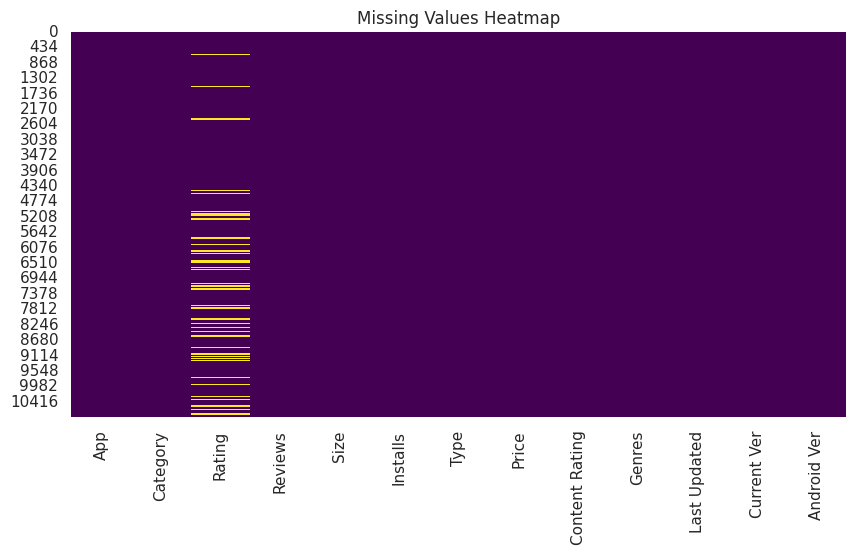

In [9]:
#vizualization for missing values using heatmap
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [10]:
# 5.Checking Duplicate Rows
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 483


In [11]:
# removing duplicates
df = df.drop_duplicates()

print(df.shape)

(10358, 13)


In [12]:
# 6.Data Cleaning
#Rating
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

df["Rating"].fillna(df["Rating"].median(), inplace=True)

# Remove invalid ratings
df = df[(df["Rating"] >= 1) & (df["Rating"] <= 5)]


In [13]:
#Reviews
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

In [14]:
#size
def convert_size(size):
    if size == "Varies with device":
        return np.nan

    if "M" in str(size):
        return float(size.replace("M",""))

    elif "k" in str(size):
        return float(size.replace("k",""))/1024

    else:
        return np.nan

df["Size"] = df["Size"].apply(convert_size)

df["Size"].fillna(df["Size"].median(), inplace=True)

In [15]:
#Installs
df["Installs"] = df["Installs"].str.replace("+","")
df["Installs"] = df["Installs"].str.replace(",","")

df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

In [16]:
#Price
df["Price"] = df["Price"].str.replace("$","")

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

In [17]:
# Last Updated
df["Last Updated"] = pd.to_datetime(df["Last Updated"], errors="coerce")

In [18]:
# 7. Missing values
df.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,0
Genres,0


In [19]:
# fill remaining missing values
df.fillna({
    "Type":"Free",
    "Content Rating":"Everyone",
    "Current Ver":"Unknown",
    "Android Ver":"Unknown"
}, inplace=True)

In [20]:
#8. Final Dataset Info
df.info()

df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 10357 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10357 non-null  object        
 1   Category        10357 non-null  object        
 2   Rating          10357 non-null  float64       
 3   Reviews         10357 non-null  int64         
 4   Size            10357 non-null  float64       
 5   Installs        10357 non-null  int64         
 6   Type            10357 non-null  object        
 7   Price           10357 non-null  float64       
 8   Content Rating  10357 non-null  object        
 9   Genres          10357 non-null  object        
 10  Last Updated    10357 non-null  datetime64[ns]
 11  Current Ver     10357 non-null  object        
 12  Android Ver     10357 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(7)
memory usage: 1.1+ MB


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up


In [21]:
# Exploratory Data Analysis

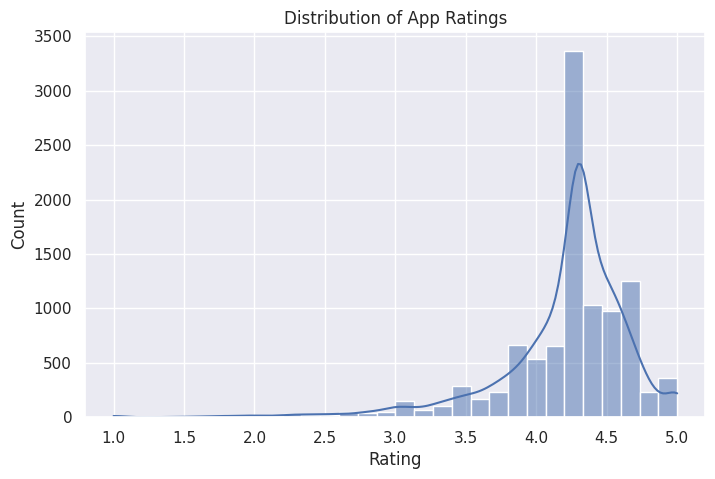

In [22]:
# 1. Rating Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["Rating"], bins=30, kde=True)

plt.title("Distribution of App Ratings")

plt.show()

## Observation 1 :
Most app ratings are concentrated between 4.0 and 4.5.
Very few apps have ratings below 3.0, indicating generally positive user feedback.

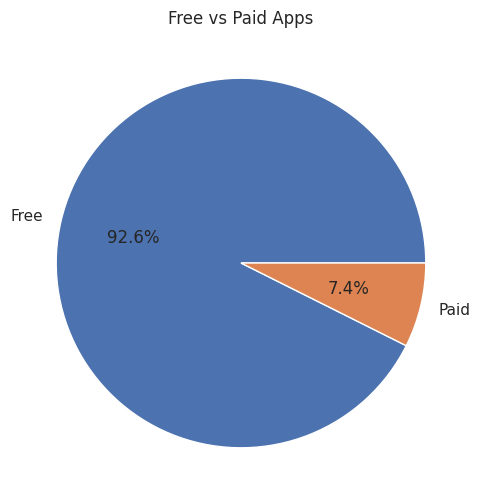

In [23]:
# 2. Free vs Paid Apps
plt.figure(figsize=(6,6))

df["Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Free vs Paid Apps")

plt.show()

## Observation 2:
92.6% of the apps are free, while only 7.4% are paid.
This shows that the Google Play Store is dominated by free applications.

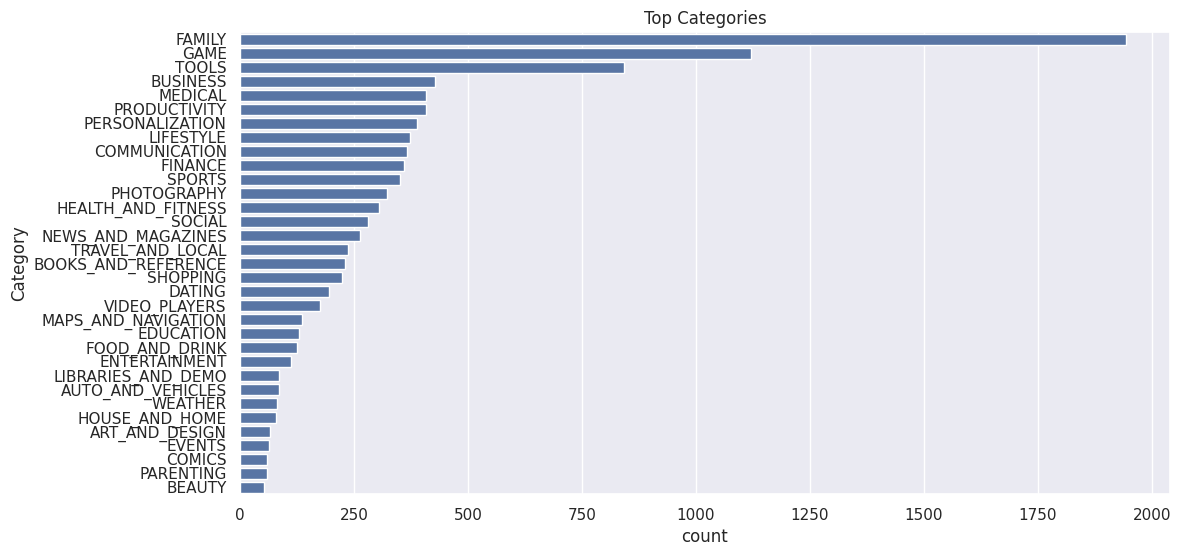

In [24]:
# 3. Top Categories
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="Category",
    order=df["Category"].value_counts().index
)

plt.title("Top Categories")

plt.show()

## Observation 3:
Family, Game, and Tools are the most populated app categories.
Categories such as Beauty, Comics, and Events contain comparatively fewer apps.

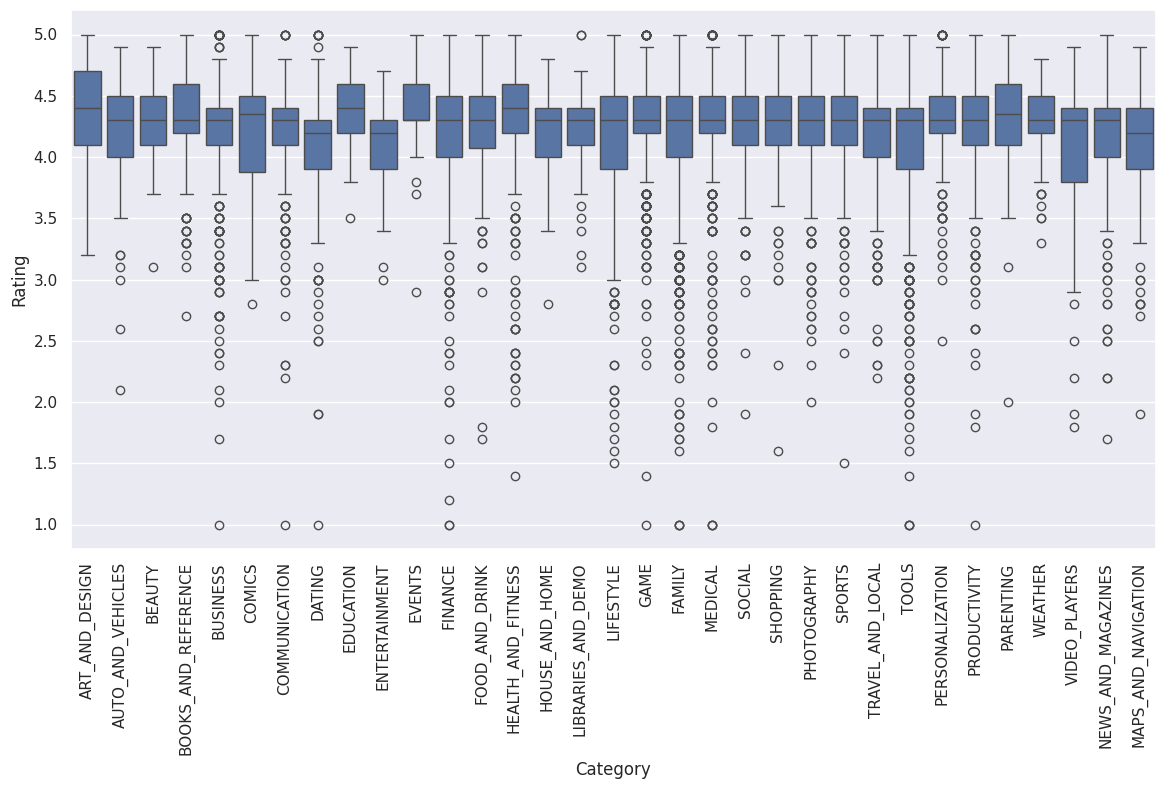

In [25]:
# 4. Rating by category
plt.figure(figsize=(14,7))

sns.boxplot(
    x="Category",
    y="Rating",
    data=df
)

plt.xticks(rotation=90)

plt.show()

## Observation 4:
Most categories have median ratings around 4.0–4.5.
Several categories contain lower-rated outliers, indicating variations in user satisfaction.


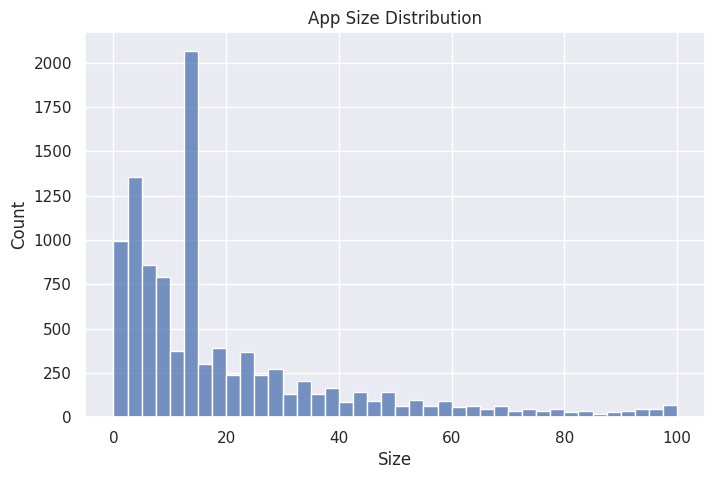

In [26]:
# 5. App Size Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["Size"], bins=40)

plt.title("App Size Distribution")

plt.show()

## Observation 5:
Most applications have sizes below 20 MB.
The distribution is right-skewed, with only a few apps exceeding 50 MB.

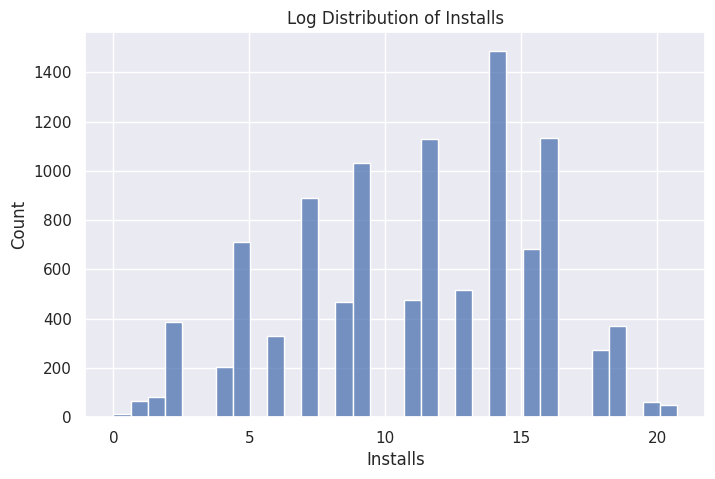

In [27]:
# 6. Installs Distribution
plt.figure(figsize=(8,5))

sns.histplot(np.log1p(df["Installs"]))

plt.title("Log Distribution of Installs")

plt.show()

## Observation 6:
After applying the logarithmic transformation, install counts appear more evenly distributed.
Most apps fall within the middle install ranges, while extremely high-install apps remain relatively few.

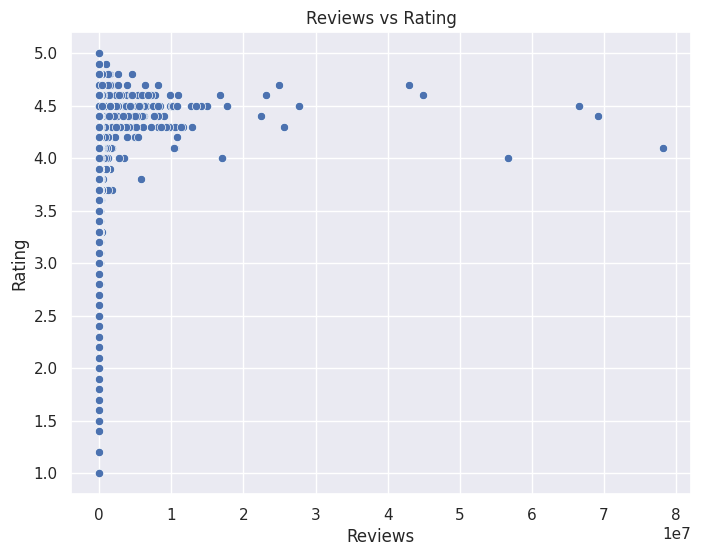

In [28]:
# 7. Rating vs Reviews
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Reviews",
    y="Rating",
    data=df
)

plt.title("Reviews vs Rating")

plt.show()

## Observation 7:
Most highly reviewed apps maintain ratings above 4.0.
There is a weak positive relationship between the number of reviews and app ratings.

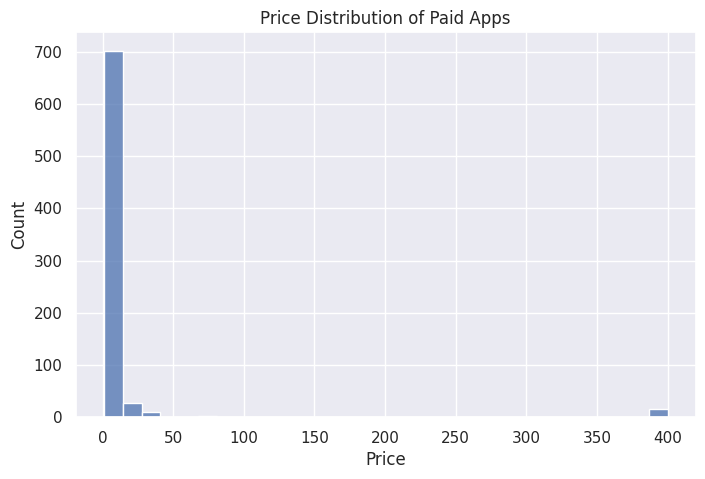

In [29]:
# 8. Paid Apps Price Distribution
paid = df[df["Type"]=="Paid"]

plt.figure(figsize=(8,5))

sns.histplot(paid["Price"], bins=30)

plt.title("Price Distribution of Paid Apps")

plt.show()

## Observation 8:
Most paid apps are priced below $20.
Only a few applications have exceptionally high prices, making them outliers.

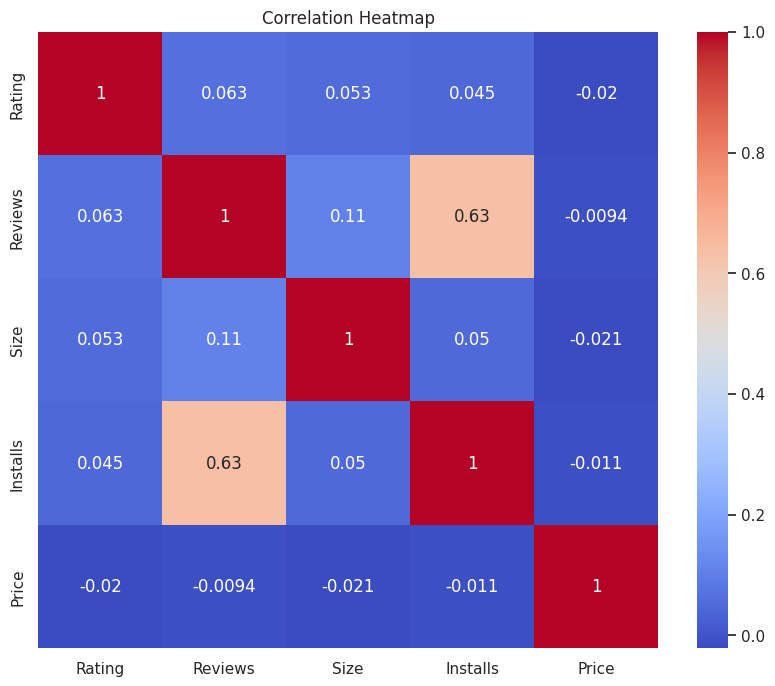

In [30]:
# 9. Correlation Heatmap
numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## Observation 9:
Reviews and Installs show the strongest positive correlation (0.63).
Other numerical features exhibit weak correlations, indicating limited linear relationships.

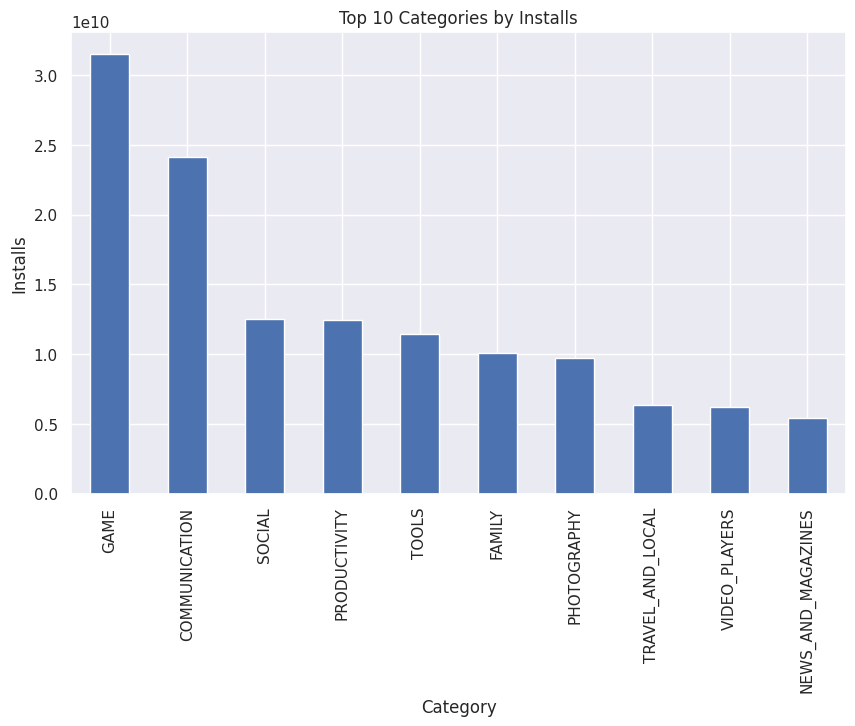

In [31]:
# 10. Top 10 Most Installed Categories
top = df.groupby("Category")["Installs"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

top.head(10).plot(kind="bar")

plt.title("Top 10 Categories by Installs")

plt.ylabel("Installs")

plt.show()

## Observation 10:
Game and Communication categories have the highest total installs.
Categories like Productivity, Tools, and Family also attract a large number of downloads.

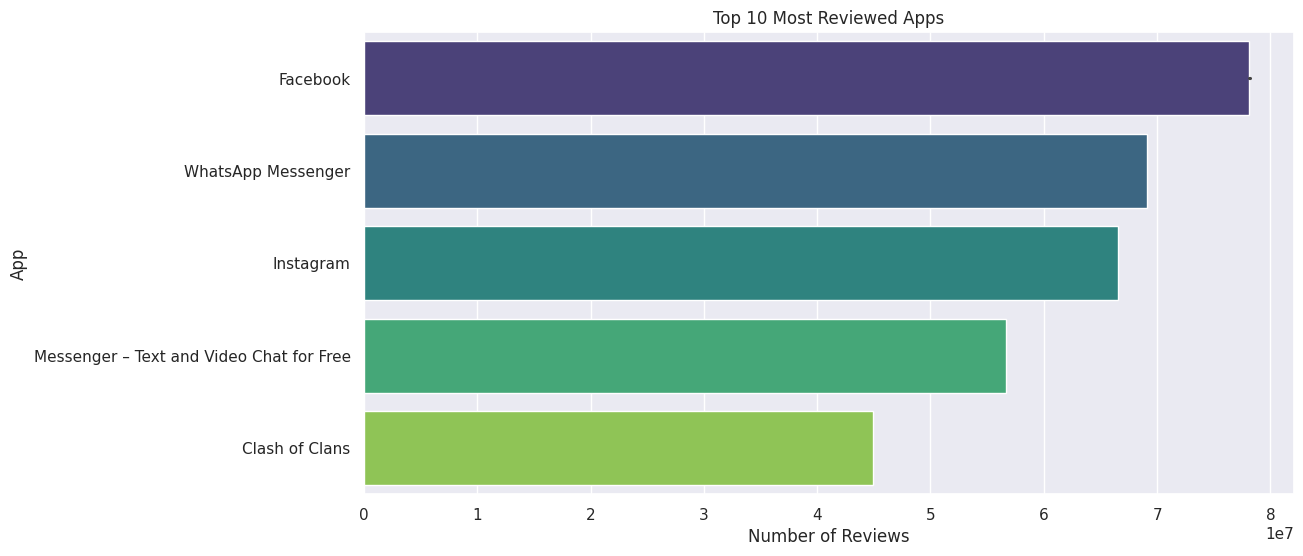

In [32]:
# 11: Top 10 Most Reviewed Apps
# Top 10 apps with the highest number of reviews
top_reviewed = df.sort_values(by='Reviews', ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_reviewed,
    x='Reviews',
    y='App',
    palette='viridis'
)

plt.title("Top 10 Most Reviewed Apps")
plt.xlabel("Number of Reviews")
plt.ylabel("App")

plt.show()

## Observation 11:
Popular applications such as Facebook, WhatsApp, Instagram, and Messenger receive the highest number of user reviews.
A larger number of reviews generally indicates a larger user base and higher engagement.
Social media and communication apps dominate the list, highlighting their widespread usage.

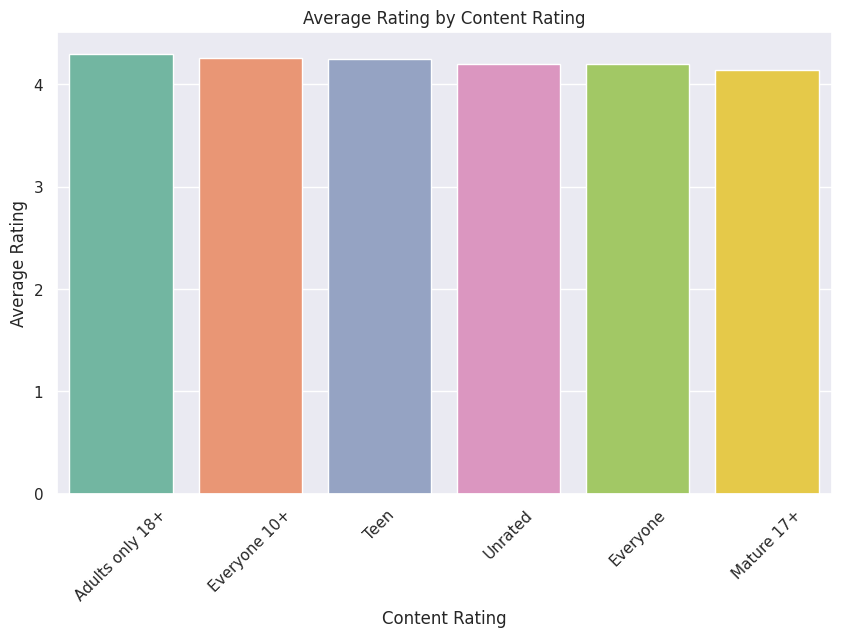

In [33]:
# 12: Average Rating by Content Rating
plt.figure(figsize=(10,6))

avg_rating = df.groupby("Content Rating")["Rating"].mean().sort_values(ascending=False)

sns.barplot(
    x=avg_rating.index,
    y=avg_rating.values,
    palette="Set2"
)

plt.title("Average Rating by Content Rating")
plt.xlabel("Content Rating")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

## Obervation 12 :
Most content rating categories have average ratings above 4.0, indicating generally positive user feedback.
Categories like Everyone and Teen contain the majority of well-rated applications.
Differences between categories are relatively small, suggesting that content rating has limited influence on app ratings.

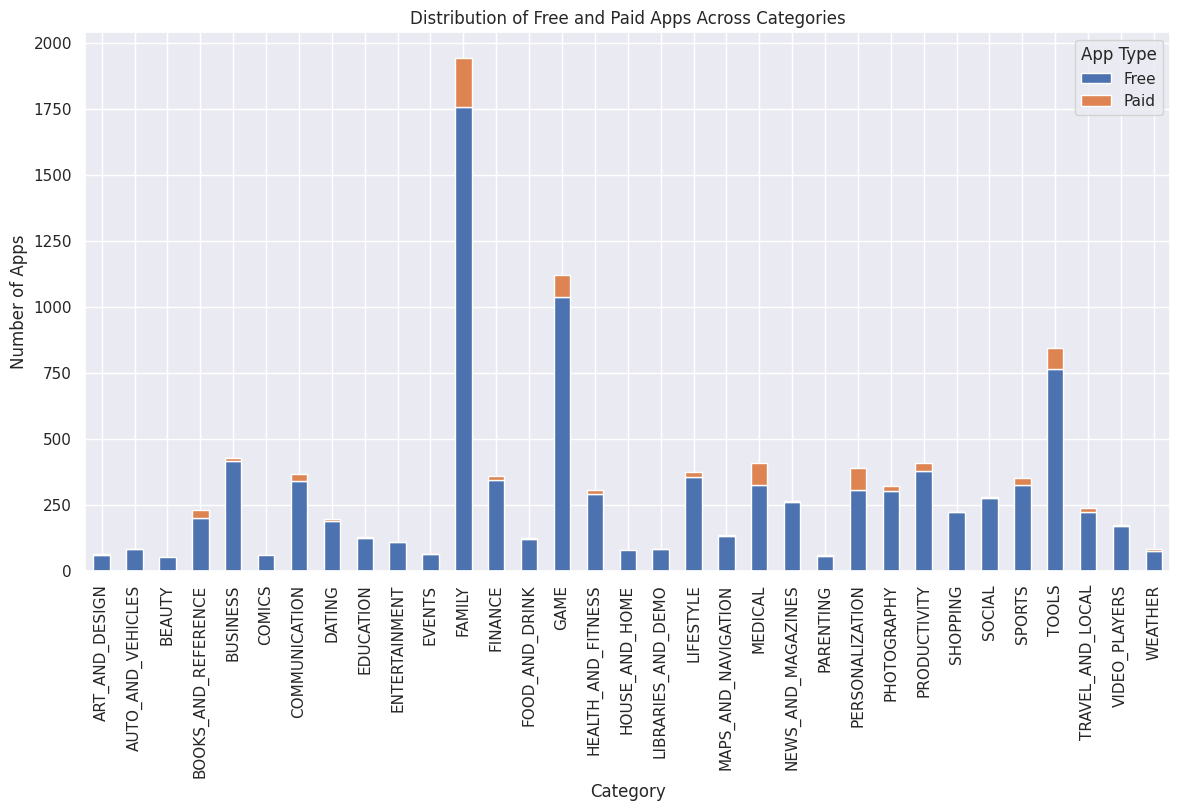

In [34]:
# 13: Distribution of Free and Paid Apps Across Categories
type_category = pd.crosstab(df["Category"], df["Type"])

type_category.plot(
    kind="bar",
    stacked=True,
    figsize=(14,7)
)

plt.title("Distribution of Free and Paid Apps Across Categories")
plt.xlabel("Category")
plt.ylabel("Number of Apps")

plt.xticks(rotation=90)

plt.legend(title="App Type")

plt.show()

## Observation 13 :
Free applications dominate almost every category.
Only a small proportion of apps are paid, regardless of category.
Categories such as Family, Game, Medical,Personalization and Tools tend to have relatively more paid apps compared to others.

# Final Insights

- The Google Play Store is predominantly composed of free applications, accounting for approximately **92.6%** of all apps.
- Most applications have ratings between **4.0 and 4.5**, indicating generally positive user satisfaction.
- **Family**, **Game**, and **Tools** are the categories with the highest number of published applications.
- **Game** and **Communication** categories achieve the highest total installs, highlighting their widespread popularity among users.
- The majority of paid applications are priced below **$20**, while only a few apps are available at significantly higher prices.
- A moderate positive correlation exists between **Reviews** and **Installs**, suggesting that widely downloaded apps tend to receive more user reviews.
- Data cleaning, including handling missing values, removing duplicates, converting data types, and eliminating invalid rating values, improved the quality and reliability of the analysis.


# Conclusion

The exploratory data analysis revealed valuable insights into app popularity, pricing, user engagement, and category distribution within the Google Play Store. These findings can help developers better understand market trends and user preferences, enabling more informed decisions when developing and publishing applications.'''